## Bank Loan analysis Report

#### Import Libraries

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import plotly.express as px

In [58]:
df = pd.read_excel(r"C:\Users\HP\Downloads\financial_loan.xlsx")

In [59]:
df.head()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,2021-02-11,2021-09-13,2021-04-13,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,2021-01-01,2021-12-14,2021-01-15,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,2021-01-05,2021-12-12,2021-01-09,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,2021-02-25,2021-12-12,2021-03-12,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,2021-01-01,2021-12-14,2021-01-15,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


In [60]:
df.tail()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
38571,803452,NJ,INDIVIDUAL,< 1 year,Joseph M Sanzari Company,C,MORTGAGE,2021-07-11,2021-05-16,2021-05-16,...,C1,60 months,Verified,100000.0,0.1986,551.64,0.1299,24250,33,31946
38572,970377,NY,INDIVIDUAL,8 years,Swat Fame,C,RENT,2021-10-11,2021-04-16,2021-05-16,...,C1,60 months,Verified,50000.0,0.0458,579.72,0.1349,25200,18,31870
38573,875376,CA,INDIVIDUAL,5 years,Anaheim Regional Medical Center,D,RENT,2021-09-11,2021-05-16,2021-05-16,...,D5,60 months,Verified,65000.0,0.1734,627.93,0.1749,25000,20,35721
38574,972997,NY,INDIVIDUAL,5 years,Brooklyn Radiology,D,RENT,2021-10-11,2021-05-16,2021-05-16,...,D5,60 months,Verified,368000.0,0.0009,612.72,0.1825,24000,9,33677
38575,682952,NY,INDIVIDUAL,4 years,Allen Edmonds,F,RENT,2021-07-11,2021-05-16,2021-05-16,...,F3,60 months,Verified,80000.0,0.0600,486.86,0.2099,18000,7,27679


#### Metadata of data

In [61]:
print("No of Rows:" , df.shape[0])

No of Rows: 38576


In [62]:
print("No of Columns:" , df.shape[1])

No of Columns: 24


In [63]:
df.info

<bound method DataFrame.info of             id address_state application_type emp_length  \
0      1077430            GA       INDIVIDUAL   < 1 year   
1      1072053            CA       INDIVIDUAL    9 years   
2      1069243            CA       INDIVIDUAL    4 years   
3      1041756            TX       INDIVIDUAL   < 1 year   
4      1068350            IL       INDIVIDUAL  10+ years   
...        ...           ...              ...        ...   
38571   803452            NJ       INDIVIDUAL   < 1 year   
38572   970377            NY       INDIVIDUAL    8 years   
38573   875376            CA       INDIVIDUAL    5 years   
38574   972997            NY       INDIVIDUAL    5 years   
38575   682952            NY       INDIVIDUAL    4 years   

                             emp_title grade home_ownership issue_date  \
0                                Ryder     C           RENT 2021-02-11   
1                       MKC Accounting     E           RENT 2021-01-01   
2                Chemat T

#### Data Type

In [64]:
df.dtypes

id                                int64
address_state                       str
application_type                    str
emp_length                          str
emp_title                        object
grade                               str
home_ownership                      str
issue_date               datetime64[us]
last_credit_pull_date    datetime64[us]
last_payment_date        datetime64[us]
loan_status                         str
next_payment_date        datetime64[us]
member_id                         int64
purpose                             str
sub_grade                           str
term                                str
verification_status                 str
annual_income                   float64
dti                             float64
installment                     float64
int_rate                        float64
loan_amount                       int64
total_acc                         int64
total_payment                     int64
dtype: object

In [65]:
df.describe()

,id,issue_date,last_credit_pull_date,last_payment_date,next_payment_date,member_id,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
count,3.857600e+04,38576,38576,38576,38576,3.857600e+04,3.857600e+04,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000
mean,6.810371e+05,2021-07-16 02:31:35.562007,2021-06-08 13:36:34.193280,2021-06-26 09:52:08.909166,2021-07-26 20:42:20.605557,8.476515e+05,6.964454e+04,0.133274,326.862965,0.120488,11296.066855,22.132544,12263.348533
min,5.473400e+04,2021-01-01 00:00:00,2021-01-08 00:00:00,2021-01-08 00:00:00,2021-02-08 00:00:00,7.069900e+04,4.000000e+03,0.000000,15.690000,0.054200,500.000000,2.000000,34.000000
25%,5.135170e+05,2021-04-11 00:00:00,2021-04-15 00:00:00,2021-03-16 00:00:00,2021-04-16 00:00:00,6.629788e+05,4.150000e+04,0.082100,168.450000,0.093200,5500.000000,14.000000,5633.000000
50%,6.627280e+05,2021-07-11 00:00:00,2021-05-16 00:00:00,2021-06-14 00:00:00,2021-07-14 00:00:00,8.473565e+05,6.000000e+04,0.134200,283.045000,0.118600,10000.000000,20.000000,10042.000000
75%,8.365060e+05,2021-10-11 00:00:00,2021-08-13 00:00:00,2021-09-15 00:00:00,2021-10-15 00:00:00,1.045652e+06,8.320050e+04,0.185900,434.442500,0.145900,15000.000000,29.000000,16658.000000
max,1.077501e+06,2021-12-12 00:00:00,2022-01-20 00:00:00,2021-12-15 00:00:00,2022-01-15 00:00:00,1.314167e+06,6.000000e+06,0.299900,1305.190000,0.245900,35000.000000,90.000000,58564.000000
std,2.113246e+05,NaN,NaN,NaN,NaN,2.668105e+05,6.429368e+04,0.066662,209.092000,0.037164,7460.746022,11.392282,9051.104777


In [66]:
df.isnull().sum()

id                          0
address_state               0
application_type            0
emp_length                  0
emp_title                1438
grade                       0
home_ownership              0
issue_date                  0
last_credit_pull_date       0
last_payment_date           0
loan_status                 0
next_payment_date           0
member_id                   0
purpose                     0
sub_grade                   0
term                        0
verification_status         0
annual_income               0
dti                         0
installment                 0
int_rate                    0
loan_amount                 0
total_acc                   0
total_payment               0
dtype: int64

In [67]:
df['emp_title'] = df['emp_title'].fillna('Unknown')

In [68]:
df.isnull().sum()

id                       0
address_state            0
application_type         0
emp_length               0
emp_title                0
grade                    0
home_ownership           0
issue_date               0
last_credit_pull_date    0
last_payment_date        0
loan_status              0
next_payment_date        0
member_id                0
purpose                  0
sub_grade                0
term                     0
verification_status      0
annual_income            0
dti                      0
installment              0
int_rate                 0
loan_amount              0
total_acc                0
total_payment            0
dtype: int64

#### Total Loan applications

In [69]:
Total_loan_application = df['id'].count()
print("Total loan application:",Total_loan_application)

Total loan application: 38576


#### MTD Total Loan application

In [70]:
latest_issue_date = df['issue_date'].max()
latest_year = latest_issue_date.year
latest_month = latest_issue_date.month

mtd_data = df[(df['issue_date'].dt.year == latest_year) & (df['issue_date'].dt.month == latest_month)]

mtd_loan_application = mtd_data['id'].count()

print(f" MTD Loan application (for {latest_issue_date.strftime('%B %Y')}): {mtd_loan_application}")

 MTD Loan application (for December 2021): 4314


#### Total Funded amount

In [71]:
total_funded_amount = df['loan_amount'].sum()
total_funded_amount_millions = total_funded_amount/1000000
print(f"Total Funded amount : ${total_funded_amount_millions:.2f}M")

Total Funded amount : $435.76M


#### MTD - Total Funded amount

In [72]:
latest_issue_date = df['issue_date'].max()
latest_year = latest_issue_date.year
latest_month = latest_issue_date.month

mtd_data = df[(df['issue_date'].dt.year == latest_year) & (df['issue_date'].dt.month == latest_month)]

mtd_total_funded_amount = mtd_data['loan_amount'].sum()
mtd_total_funded_amount_millions = mtd_total_funded_amount/1000000
print(f"MTD Total Funded amount : ${mtd_total_funded_amount_millions:.2f}M")

MTD Total Funded amount : $53.98M


#### Total amount received

In [73]:
total_amount_received = df['total_payment'].sum()
total_amount_recevied_millions = total_amount_received/1000000
print(f"Total amount received : ${total_amount_recevied_millions:.2f}M")

Total amount received : $473.07M


#### MTD Total amount received

In [74]:
latest_issue_date = df['issue_date'].max()
latest_year = latest_issue_date.year
latest_month = latest_issue_date.month

mtd_data = df[(df['issue_date'].dt.year == latest_year) & (df['issue_date'].dt.month == latest_month)]

mtd_total_amount_received = mtd_data['total_payment'].sum()
mtd_total_amount_received_millions = mtd_total_funded_amount/1000000
print(f"MTD Total amount received : ${mtd_total_funded_amount_millions:.2f}M")

MTD Total amount received : $53.98M


#### average interest rate

In [75]:
average_interest_rate = df['int_rate'].mean()*100
print(f"average interest rate: {average_interest_rate:.2f}%")

average interest rate: 12.05%


#### average debt-to-income ratio(DTI)

In [76]:
average_dti = df['dti'].mean()*100
print(f"average dti: {average_dti:.2f}%")

average dti: 13.33%


### Good Loan Metrics

In [77]:
good_loans = df[df['loan_status'].isin(["Fully Paid","Current"])]

total_loan_application = df['id'].count()

good_loan_applications = good_loans['id'].count()
good_loan_funded_amount = good_loans['loan_amount'].sum()
good_loan_received = good_loans['total_payment'].sum()

good_loan_funded_amount_millions = good_loan_funded_amount/ 1000000
good_loan_received_millions = good_loan_received / 1000000

good_loan_percentage = (good_loan_applications/total_loan_application) * 100

print(f"Good loan application:", good_loan_applications)
print(f"Good loan funded amount (in millions): ${good_loan_funded_amount_millions:.2f}M")
print(f"Good loan total recevied (in millions): ${good_loan_received_millions:.2f}M")
print(f"Percentage of good loan application: {good_loan_percentage:.2f}%")

Good loan application: 33243
Good loan funded amount (in millions): $370.22M
Good loan total recevied (in millions): $435.79M
Percentage of good loan application: 86.18%


#### Bad Loan Metrics

In [78]:
bad_loans = df[df['loan_status'].isin(["Charged Off"])]


bad_loan_applications = bad_loans['id'].count()
bad_loan_funded_amount = bad_loans['loan_amount'].sum()
bad_loan_received = bad_loans['total_payment'].sum()

bad_loan_funded_amount_millions = bad_loan_funded_amount/ 1000000
bad_loan_received_millions = bad_loan_received / 1000000

bad_loan_percentage = (bad_loan_applications/total_loan_application) * 100

print(f"Bad loan application:", bad_loan_applications)
print(f"Bad loan funded amount (in millions): ${bad_loan_funded_amount_millions:.2f}M")
print(f"Bad loan total recevied (in millions): ${bad_loan_received_millions:.2f}M")
print(f"Percentage of bad loan application: {bad_loan_percentage:.2f}%")

Bad loan application: 5333
Bad loan funded amount (in millions): $65.53M
Bad loan total recevied (in millions): $37.28M
Percentage of bad loan application: 13.82%


#### Monthly Trends by Issue date for total funded amount

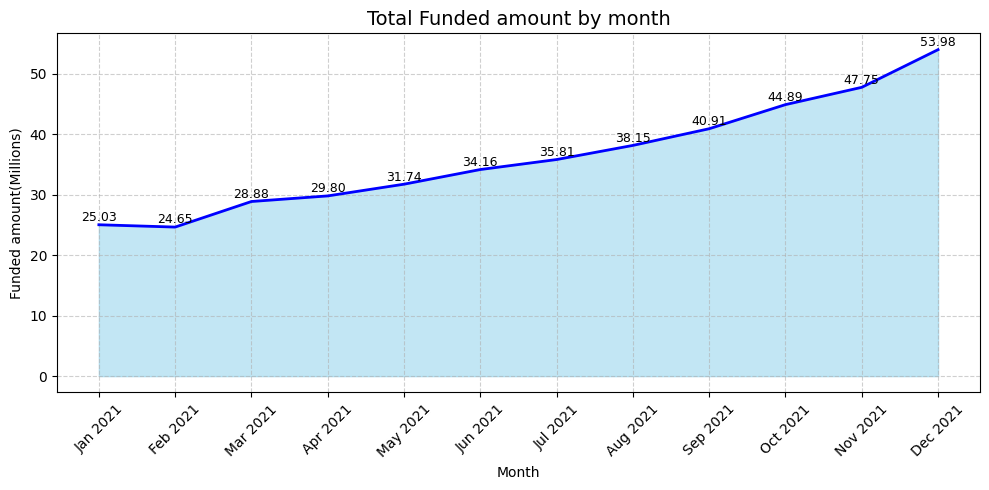

In [79]:
monthly_funded = (
    df.sort_values('issue_date')
    .assign(month_name = lambda x: x['issue_date'].dt.strftime('%b %Y'))
    .groupby('month_name',sort=False)['loan_amount']
    .sum()
    .div(1000000)
    .reset_index(name='loan_amount_millions')
)

plt.figure(figsize=(10,5))
plt.fill_between(monthly_funded['month_name'],monthly_funded['loan_amount_millions'],color='skyblue',alpha=0.5)
plt.plot(monthly_funded['month_name'],monthly_funded['loan_amount_millions'],color='blue',linewidth=2)

for i, row in monthly_funded.iterrows():
    plt.text(i, row['loan_amount_millions'] + 0.1, f"{row['loan_amount_millions']:.2f}",
             ha='center', va='bottom', fontsize=9, rotation=0, color='black')

plt.title('Total Funded amount by month',fontsize=14)
plt.xlabel('Month')
plt.ylabel('Funded amount(Millions)')
plt.xticks(ticks=range(len(monthly_funded)),labels=monthly_funded['month_name'],rotation=45)
plt.grid(True,linestyle='--',alpha=0.6)
plt.tight_layout()
plt.show()

#### Monthly Trends by Issue date for total amount recevied

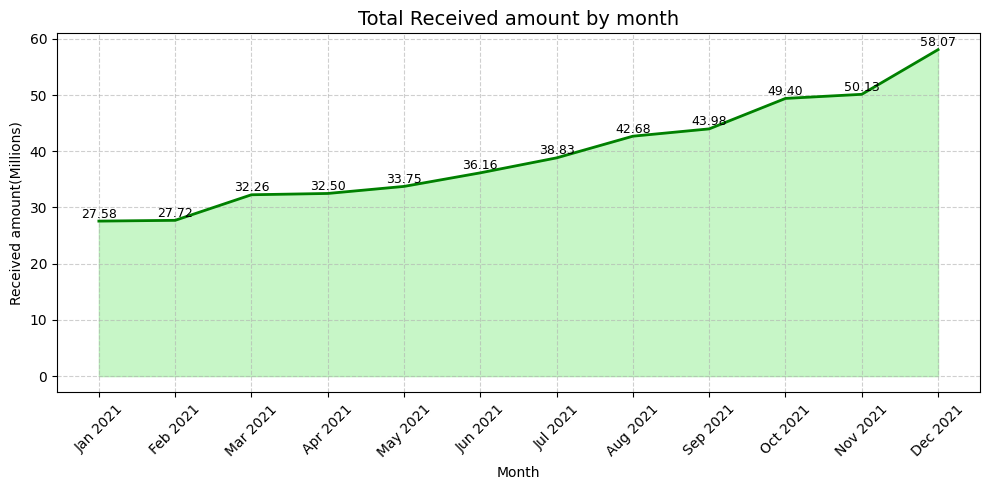

In [80]:
monthly_received = (
    df.sort_values('issue_date')
    .assign(month_name = lambda x: x['issue_date'].dt.strftime('%b %Y'))
    .groupby('month_name',sort=False)['total_payment']
    .sum()
    .div(1000000)
    .reset_index(name='received_amount_millions')
)

plt.figure(figsize=(10,5))
plt.fill_between(monthly_received['month_name'],monthly_received['received_amount_millions'],color='lightgreen',alpha=0.5)
plt.plot(monthly_received['month_name'],monthly_received['received_amount_millions'],color='green',linewidth=2)

for i, row in monthly_received.iterrows():
    plt.text(i, row['received_amount_millions'] + 0.1, f"{row['received_amount_millions']:.2f}",
             ha='center', va='bottom', fontsize=9, rotation=0, color='black')

plt.title('Total Received amount by month',fontsize=14)
plt.xlabel('Month')
plt.ylabel('Received amount(Millions)')
plt.xticks(ticks=range(len(monthly_received)),labels=monthly_received['month_name'],rotation=45)
plt.grid(True,linestyle='--',alpha=0.6)
plt.tight_layout()
plt.show()

#### Monthly Trends by Issue date for total Loan application

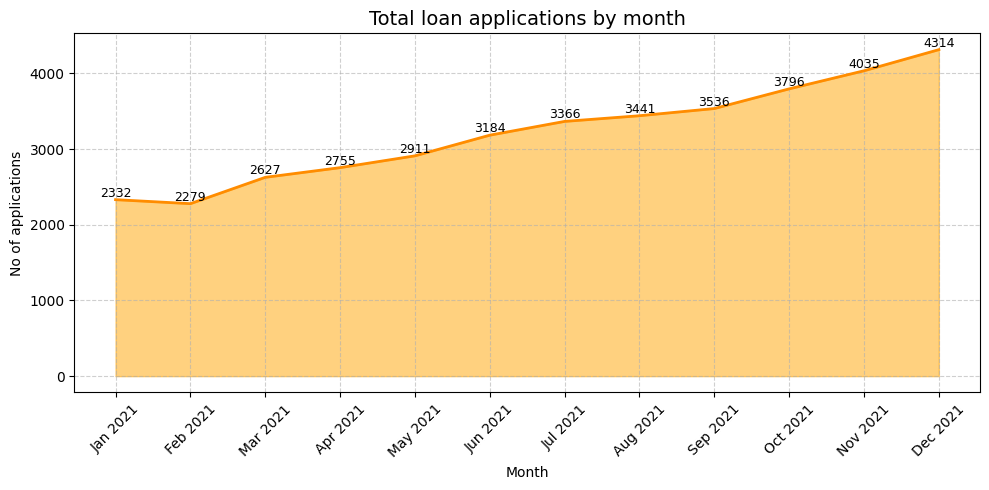

In [81]:
monthly_application = (
    df.sort_values('issue_date')
    .assign(month_name = lambda x: x['issue_date'].dt.strftime('%b %Y'))
    .groupby('month_name',sort=False)['id']
    .count()
    .reset_index(name='loan_applications_count')
)

plt.figure(figsize=(10,5))
plt.fill_between(monthly_application['month_name'],monthly_application['loan_applications_count'],color='orange',alpha=0.5)
plt.plot(monthly_application['month_name'],monthly_application['loan_applications_count'],color='darkorange',linewidth=2)

for i, row in monthly_application.iterrows():
    plt.text(i, row['loan_applications_count'] + 0.1, f"{row['loan_applications_count']}",
             ha='center', va='bottom', fontsize=9, rotation=0, color='black')

plt.title('Total loan applications by month',fontsize=14)
plt.xlabel('Month')
plt.ylabel('No of applications')
plt.xticks(ticks=range(len(monthly_application)),labels=monthly_application['month_name'],rotation=45)
plt.grid(True,linestyle='--',alpha=0.6)
plt.tight_layout()
plt.show()

#### Regional analysis by sales for total funded amount

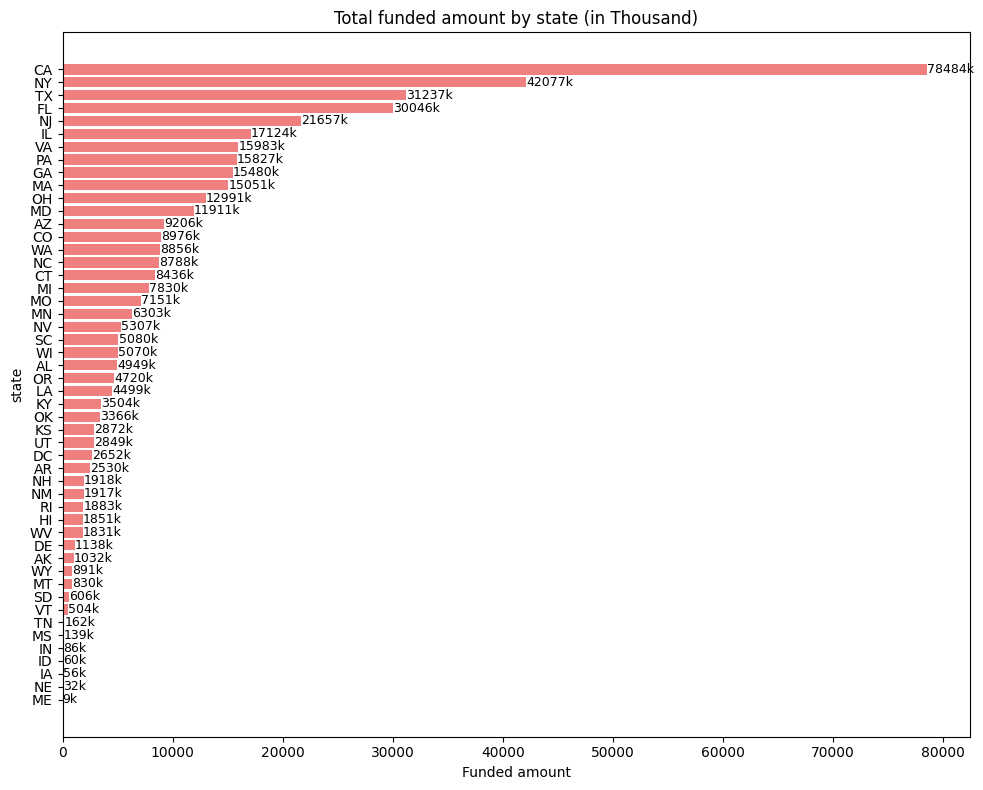

In [82]:
state_funding = df.groupby('address_state')['loan_amount'].sum().sort_values(ascending=True)
state_funding_thousand = state_funding / 1000

plt.figure(figsize=(10,8))
bars = plt.barh(state_funding_thousand.index,state_funding_thousand.values,color='lightcoral')
for bar in bars:
    width = bar.get_width()
    plt.text(width + 10, bar.get_y() + bar.get_height() / 2,
             f'{width:.0f}k', va= 'center',fontsize = 9)


plt.title('Total funded amount by state (in Thousand)')
plt.xlabel('Funded amount')
plt.ylabel('state')
plt.tight_layout()
plt.show()


#### Regional analysis by sales for total Recevied amount

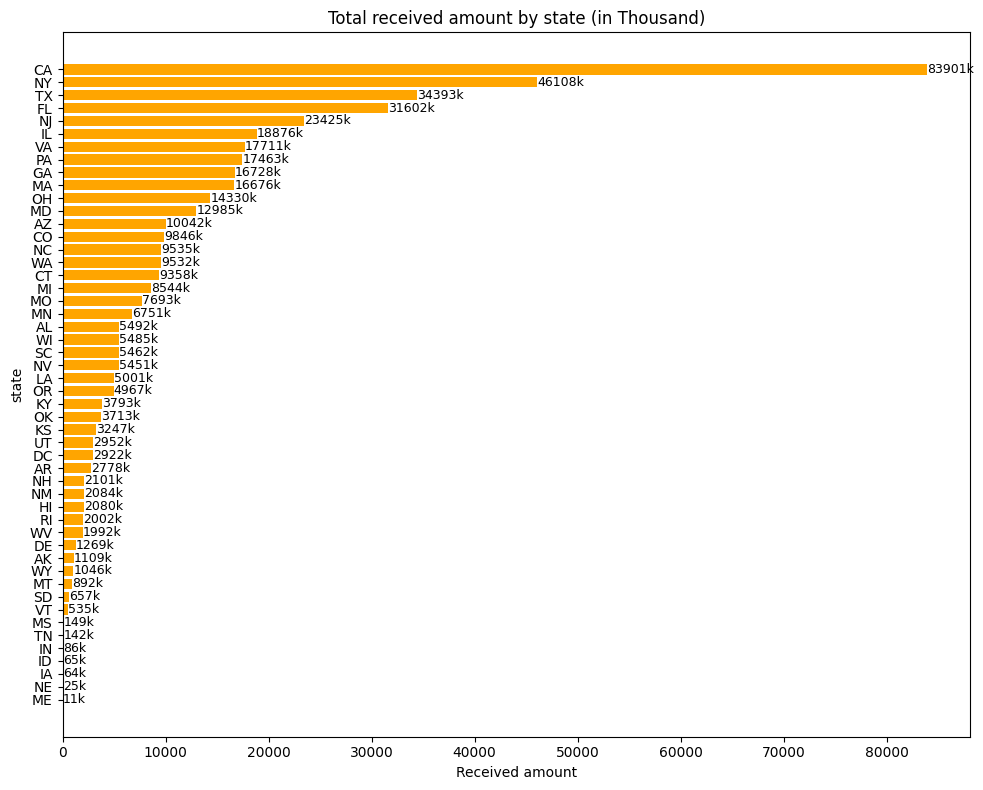

In [83]:
state_receiving = df.groupby('address_state')['total_payment'].sum().sort_values(ascending=True)
state_receiving_thousand = state_receiving / 1000

plt.figure(figsize=(10,8))
bars = plt.barh(state_receiving_thousand.index,state_receiving_thousand.values,color='orange')
for bar in bars:
    width = bar.get_width()
    plt.text(width + 10, bar.get_y() + bar.get_height() / 2,
             f'{width:.0f}k', va= 'center',fontsize = 9)


plt.title('Total received amount by state (in Thousand)')
plt.xlabel('Received amount')
plt.ylabel('state')
plt.tight_layout()
plt.show()

#### Regional analysis by loan applications 

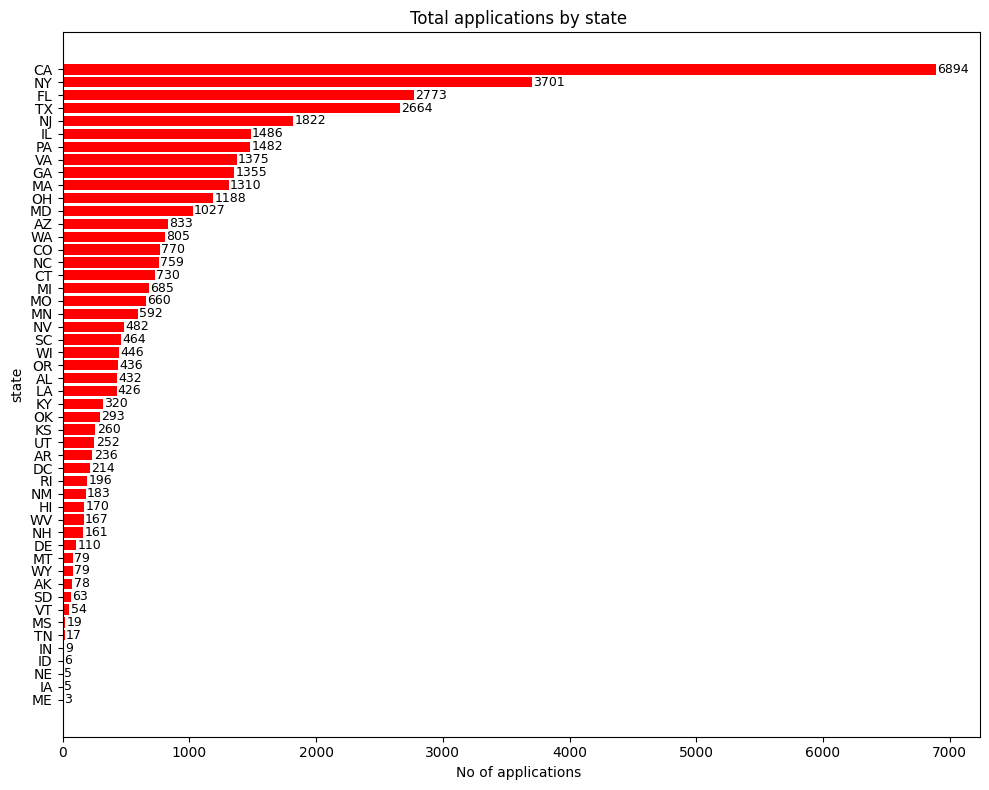

In [84]:
state_applications = df.groupby('address_state')['id'].count().sort_values(ascending=True)

plt.figure(figsize=(10,8))
bars = plt.barh(state_applications.index,state_applications.values,color='red')
for bar in bars:
    width = bar.get_width()
    plt.text(width + 10, bar.get_y() + bar.get_height() / 2,
             f'{width:.0f}', va= 'center',fontsize = 9)


plt.title('Total applications by state ')
plt.xlabel('No of applications ')
plt.ylabel('state')
plt.tight_layout()
plt.show()

#### Loan Term analysis by total funded amount

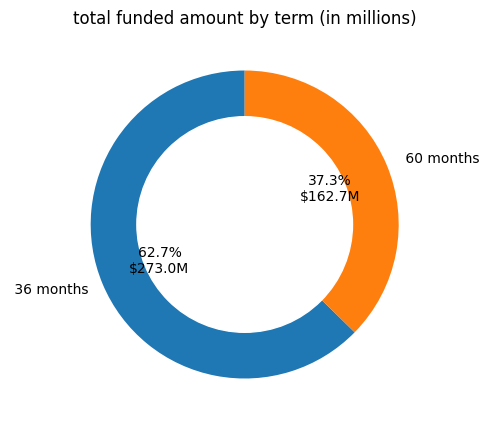

In [85]:
term_funding_millions = df.groupby('term')['loan_amount'].sum() / 1000000

plt.figure(figsize=(5,5))
plt.pie(
    term_funding_millions,
    labels=term_funding_millions.index,
    autopct=lambda p: f"{p:.1f}%\n${p*sum(term_funding_millions)/100:.1f}M",
    startangle=90,
    wedgeprops={'width':0.4})

plt.gca().add_artist(plt.Circle((0,0),0.70, color='white'))
plt.title('total funded amount by term (in millions)' )
plt.show()

#### Loan Term analysis by total Received amount

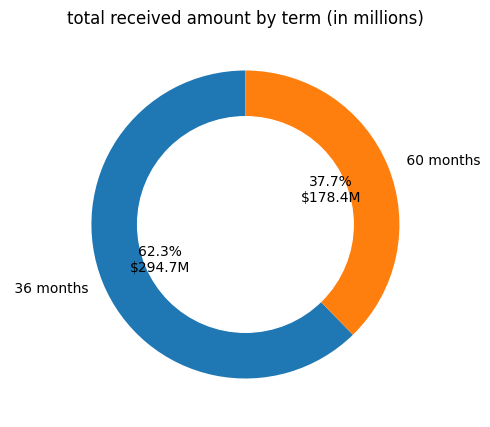

In [86]:
term_receiving_millions = df.groupby('term')['total_payment'].sum() / 1000000

plt.figure(figsize=(5,5))
plt.pie(
    term_receiving_millions,
    labels=term_receiving_millions.index,
    autopct=lambda p: f"{p:.1f}%\n${p*sum(term_receiving_millions)/100:.1f}M",
    startangle=90,
    wedgeprops={'width':0.4})

plt.gca().add_artist(plt.Circle((0,0),0.70, color='white'))
plt.title('total received amount by term (in millions)' )
plt.show()

#### Loan Term analysis by total application

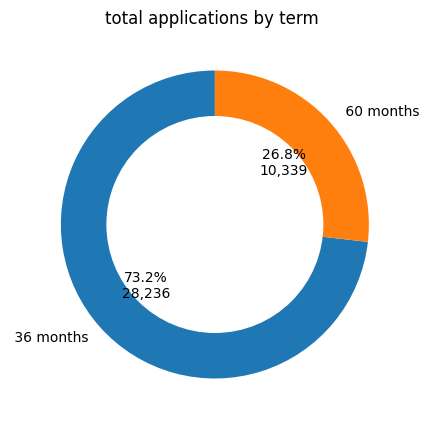

In [87]:
term_applications = df.groupby('term')['id'].count()

plt.figure(figsize=(5,5))
plt.pie(
    term_applications,
    labels=term_applications.index,
    autopct=lambda p: f"{p:.1f}%\n{int(p*sum(term_applications/100)):,}",
    startangle=90,
    wedgeprops={'width':0.4})

plt.gca().add_artist(plt.Circle((0,0),0.70, color='white'))
plt.title('total applications by term ' )
plt.show()

#### Employee Length by total funded amount

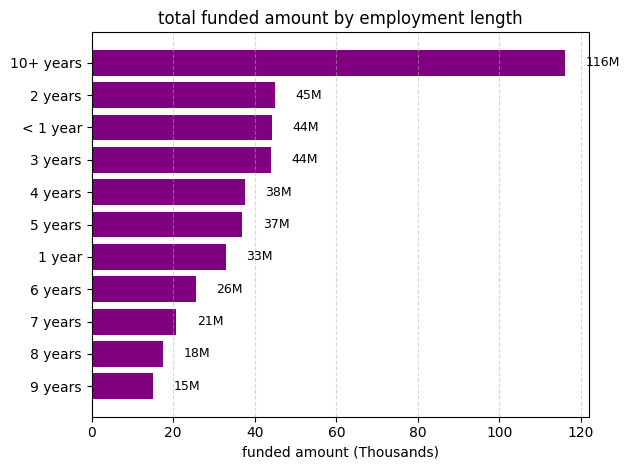

In [88]:
emp_funding = df.groupby('emp_length')['loan_amount'].sum().sort_values()/1000000

plt.Figure(figsize=(10,6))
bars = plt.barh(emp_funding.index, emp_funding, color = 'purple')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 5, bar.get_y() + bar.get_height() / 2,
             f"{width:,.0f}M", va= 'center', fontsize= 9)

plt.xlabel("funded amount (Thousands)")
plt.title("total funded amount by employment length")
plt.grid(axis='x',linestyle='--',alpha=0.5)
plt.tight_layout()
plt.show()

#### Employee Length by total Received amount

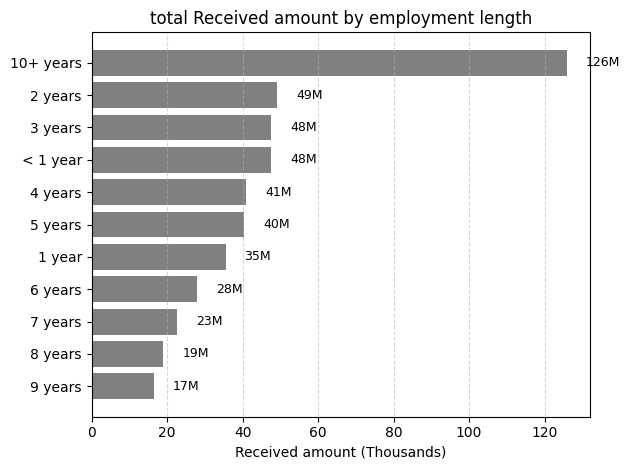

In [89]:
emp_receiving = df.groupby('emp_length')['total_payment'].sum().sort_values()/1000000

plt.Figure(figsize=(10,7))
bars = plt.barh(emp_receiving.index, emp_receiving, color = 'grey')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 5, bar.get_y() + bar.get_height() / 2,
             f"{width:,.0f}M", va= 'center', fontsize= 9)

plt.xlabel("Received amount (Thousands)")
plt.title("total Received amount by employment length")
plt.grid(axis='x',linestyle='--',alpha=0.5)
plt.tight_layout()
plt.show()

#### Employee Length by total applications

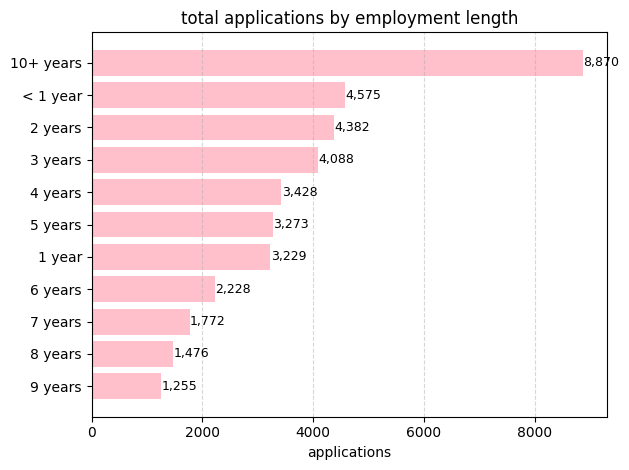

In [90]:
emp_applications = df.groupby('emp_length')['id'].count().sort_values()

plt.Figure(figsize=(10,6))
bars = plt.barh(emp_applications.index, emp_applications, color = 'pink')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 5, bar.get_y() + bar.get_height() / 2,
             f"{width:,}", va= 'center', fontsize= 9)

plt.xlabel("applications")
plt.title("total applications by employment length")
plt.grid(axis='x',linestyle='--',alpha=0.5)
plt.tight_layout()
plt.show()

#### Loan purpose by total funded amount

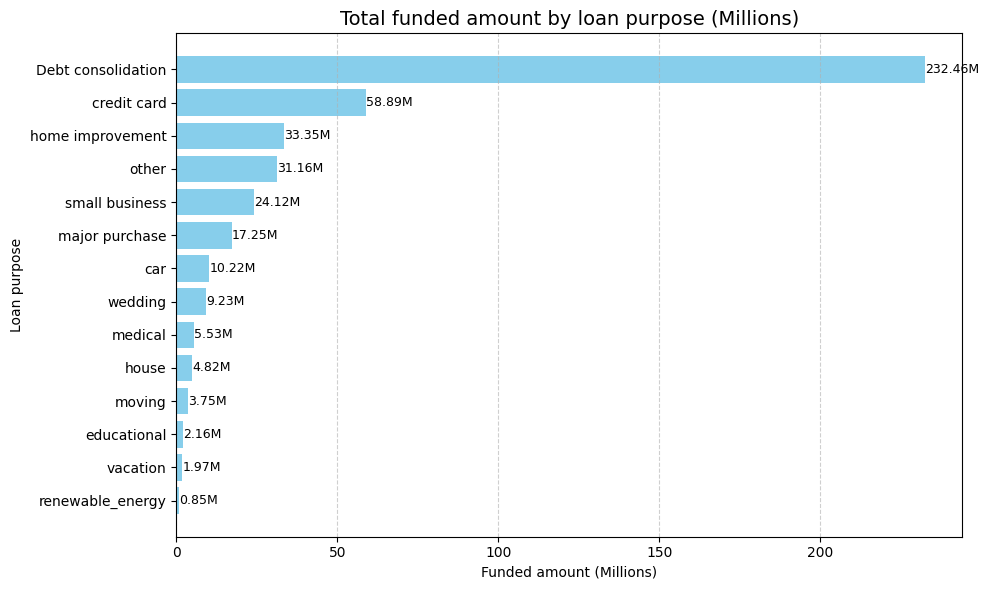

In [91]:
purpose_funding_millions = (df.groupby('purpose')['loan_amount'].sum().sort_values()/1000000)

plt.figure(figsize=(10,6))
bars = plt.barh(purpose_funding_millions.index,purpose_funding_millions.values,color='skyblue')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.1, bar.get_y() + bar.get_height()/2,
             f'{width:.2f}M', va = 'center', fontsize=9)

plt.title('Total funded amount by loan purpose (Millions)', fontsize=14)
plt.xlabel('Funded amount (Millions)')
plt.ylabel('Loan purpose')
plt.grid(axis='x',linestyle= '--', alpha = 0.6)
plt.tight_layout()
plt.show()

#### Loan purpose by total Received amount

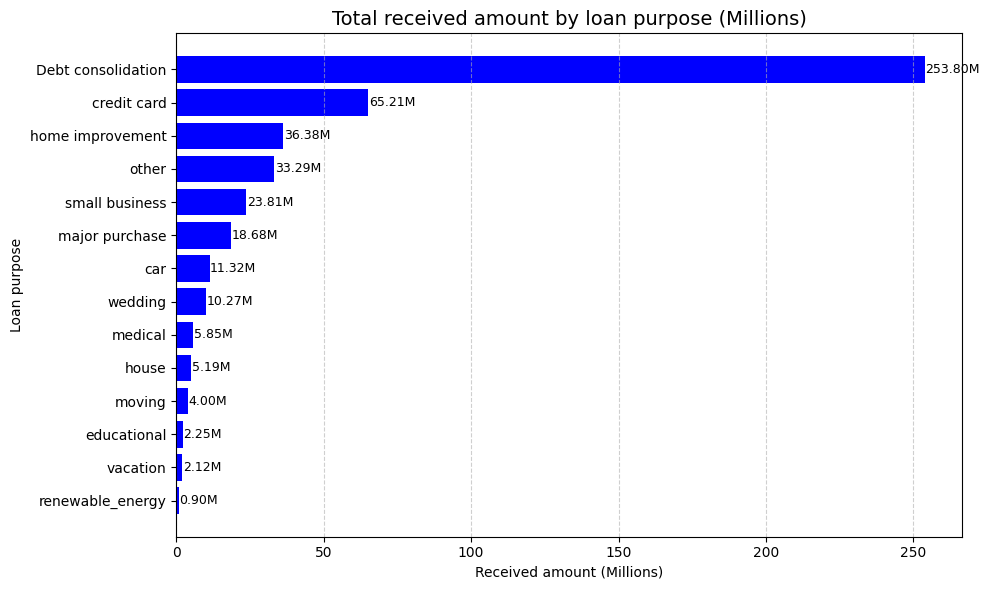

In [92]:
purpose_receiving_millions = (df.groupby('purpose')['total_payment'].sum().sort_values()/1000000)

plt.figure(figsize=(10,6))
bars = plt.barh(purpose_receiving_millions.index,purpose_receiving_millions.values,color='blue')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.1, bar.get_y() + bar.get_height()/2,
             f'{width:.2f}M', va = 'center', fontsize=9)

plt.title('Total received amount by loan purpose (Millions)', fontsize=14)
plt.xlabel('Received amount (Millions)')
plt.ylabel('Loan purpose')
plt.grid(axis='x',linestyle= '--', alpha = 0.6)
plt.tight_layout()
plt.show()

#### Loan purpose by total applications

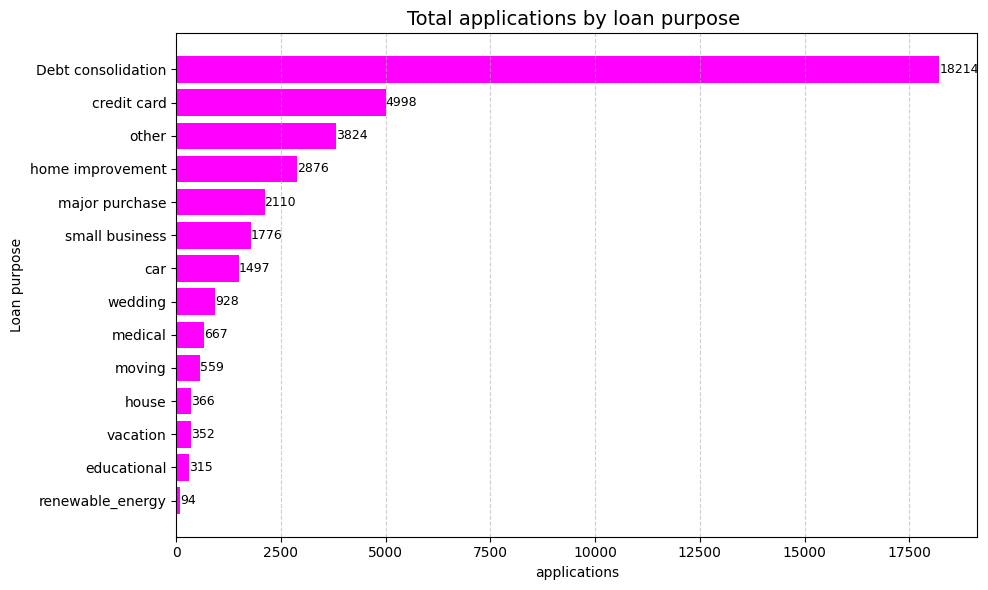

In [93]:
purpose_applications = df.groupby('purpose')['id'].count().sort_values()

plt.figure(figsize=(10,6))
bars = plt.barh(purpose_applications.index,purpose_applications.values,color='magenta')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.1, bar.get_y() + bar.get_height()/2,
             f'{width:.,}', va = 'center', fontsize=9)

plt.title('Total applications by loan purpose ', fontsize=14)
plt.xlabel('applications')
plt.ylabel('Loan purpose')
plt.grid(axis='x',linestyle= '--', alpha = 0.6)
plt.tight_layout()
plt.show()

#### Home ownership by total funded amount

In [94]:
home_funding = df.groupby('home_ownership')['loan_amount'].sum().reset_index()
home_funding['loan_amount_millions'] = home_funding['loan_amount'] / 1000000

fig = px.treemap(
    home_funding,
    path=['home_ownership'],
    values ='loan_amount_millions',
    color = 'loan_amount_millions',
    color_continuous_scale='blues',
    title='Total Funded amount by Home ownership (millions)'
)

fig.show()

#### Home ownership by total received amount

In [95]:
home_receiving = df.groupby('home_ownership')['total_payment'].sum().reset_index()
home_receiving['loan_amount_millions'] = home_receiving['total_payment'] / 1000000

fig = px.treemap(
    home_receiving,
    path=['home_ownership'],
    values ='loan_amount_millions',
    color = 'loan_amount_millions',
    color_continuous_scale='reds',
    title='Total Received amount by Home ownership (millions)'
)

fig.show()

In [97]:
home_apps = df.groupby('home_ownership')['id'].count().reset_index()
home_apps.columns = ['home_ownership','application_count']

fig = px.treemap(
    home_apps,
    path=['home_ownership'],
    values ='application_count',
    color = 'application_count',
    color_continuous_scale='blues',
    title='Total loan applications by Home ownership'
)

fig.show()